## Model Training

#### 1.1 Import data nad required packages

In [1]:
# Basic Import

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


#### 1.2 Import CSV Dataset as Pandas DataFrame

In [2]:
df = pd.read_csv("data/students.csv")

In [3]:
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


#### Preparing X and Y variables

In [4]:
X = df.drop(['math_score'], axis = 1)

In [5]:
X.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93


In [6]:
y = df['math_score']

In [7]:
y.head(3)

0    72
1    69
2    90
Name: math_score, dtype: int64

In [8]:
## column trnasformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("numeric", num_transformer, num_features),
        ("categorical", cat_transformer, cat_features)
    ]
)

C:\Users\ERIC\AppData\Local\Temp\ipykernel_896\1809525485.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [9]:
X = preprocessor.fit_transform(X)

In [10]:
# split the dataset into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [11]:
X_train.shape,  X_test.shape

((800, 19), (200, 19))

### Create an Evaluate function that gives all metrics after model training

In [12]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)  # Train the models

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print("Model Performance for Training Set")
    print("- Root mean square error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute error: {:.4f}".format(model_train_mae))
    print("- R2 Score {:.4f}".format(model_train_r2))

    print("---"*30)

    
    print("- Model Performance for Test Set")
    print("- Root mean square error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute error: {:.4f}".format(model_test_mae))
    print("- R2 Score {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("==="*30)
    print("\n")




Linear Regression
Model Performance for Training Set
- Root mean square error: 5.3231
- Mean Absolute error: 4.2667
- R2 Score 0.8743
------------------------------------------------------------------------------------------
- Model Performance for Test Set
- Root mean square error: 5.3940
- Mean Absolute error: 4.2148
- R2 Score 0.8804


Lasso
Model Performance for Training Set
- Root mean square error: 6.5938
- Mean Absolute error: 5.2063
- R2 Score 0.8071
------------------------------------------------------------------------------------------
- Model Performance for Test Set
- Root mean square error: 6.5197
- Mean Absolute error: 5.1579
- R2 Score 0.8253


Ridge
Model Performance for Training Set
- Root mean square error: 5.3233
- Mean Absolute error: 4.2650
- R2 Score 0.8743
------------------------------------------------------------------------------------------
- Model Performance for Test Set
- Root mean square error: 5.3904
- Mean Absolute error: 4.2111
- R2 Score 0.8806


K

### Results

In [14]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model Name', 'R2 Score']).sort_values(by=['R2 Score'], ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.854226
7,CatBoost Regressor,0.851632
8,AdaBoost Regressor,0.847776
1,Lasso,0.825320
6,XGB Regressor,0.821221
3,K-Neighbors Regressor,0.783770
4,Decision Tree,0.739540


## Linear Regression

In [15]:
lin_model= LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print(" Accuracy of the model is %.4f" %score)

 Accuracy of the model is 88.0433


### Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

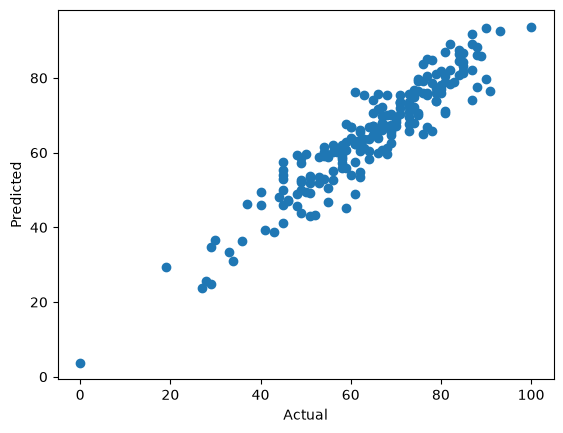

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

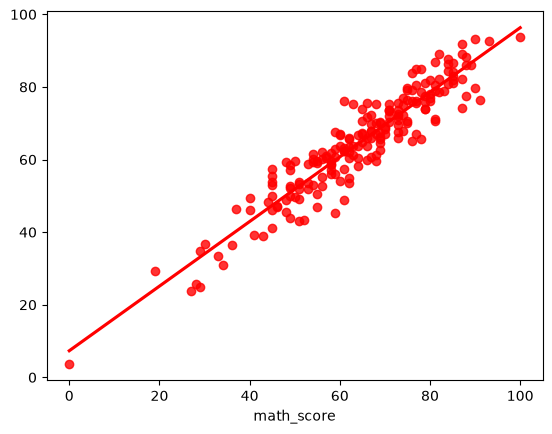

In [17]:
sns.regplot(x = y_test, y = y_pred, ci = None, color = 'red')

In [18]:
pred_df = pd.DataFrame({'Actual Values': y_test, 'Predicted Values':y_pred, 'Difference':y_test-y_pred})
pred_df
                       

,Actual Values,Predicted Values,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
